# 02 — POMO-style Active Search pour le CVRP

Ce notebook entraîne un modèle **POMO-style Active Search** sur des instances CVRP.

Objectifs :
- utiliser le même format de métriques finales que les heuristiques et Q-learning ;
- produire les courbes d'apprentissage ;
- séparer les temps : entraînement, inférence, post-traitement 2-opt et total ;
- évaluer plusieurs seeds ;
- générer les cartes des routes obtenues.

> Remarque méthodologique : ce notebook implémente une version expérimentale **POMO-style Active Search**, inspirée de l’idée POMO des rollouts multiples. Il ne s’agit pas d’une reproduction complète officielle du modèle POMO original.

In [1]:
from pathlib import Path
import sys
import random
import json
from time import perf_counter
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

# Permet d'importer src/ même si le notebook est lancé depuis notebooks/
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    ROOT_DIR = CURRENT_DIR.parent
else:
    ROOT_DIR = CURRENT_DIR

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.cvrp.data.parser import load_cvrp_instance
from src.cvrp.core.metrics import FINAL_RESULT_COLUMNS, build_final_result_row
from src.cvrp.core.validation import validate_solution
from src.cvrp.heuristics.two_opt import two_opt_solution
from src.cvrp.rl.env import CVRPEnv
from src.cvrp.visualization.plot_routes import plot_solution_routes

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("ROOT_DIR :", ROOT_DIR)
print("DEVICE   :", DEVICE)

if torch.cuda.is_available():
    print("GPU      :", torch.cuda.get_device_name(0))

ROOT_DIR : f:\code\projects\tfc\export_windows
DEVICE   : cuda
GPU      : NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
CONFIG = {
    "instance_paths": [
        "data/instances/A-n32-k5.vrp",
        "data/instances/A-n37-k5.vrp",
        "data/instances/A-n39-k6.vrp",
    ],

    "reference_costs": {
        "A-n32-k5": 784,
        "A-n37-k5": 669,
        "A-n39-k6": 831,

    },

    # Pour les résultats finaux du mémoire, garder au moins 5 seeds.
    "seeds": [42, 43, 44, 45, 46],

    # Pour un test rapide, mettre 100 ou 200.
    # Pour les résultats finaux, garder 1000 ou 1500.
    "episodes": 500,

    # Nombre de rollouts par épisode.
    # 16 est un bon compromis pour A-n32-k5.
    "pomo_size": 16,

    # Évaluations par sampling à la fin.
    "sampled_eval_rollouts": 128,

    # Sécurité pour éviter les boucles.
    "max_steps": 500,

    # Réseau
    "input_dim": 9,
    "hidden_dim": 128,
    "dropout": 0.0,

    # Optimisation
    "learning_rate": 1e-3,
    "entropy_coef": 0.01,
    "grad_clip_norm": 1.0,

    # Environnement
    "invalid_action_penalty": -1000.0,
    "incomplete_solution_penalty": -5000.0,
    "completion_bonus": 100.0,
    "distance_reward_scale": 1.0,

    # Sauvegardes
    "output_dir": "results/pomo",
    "figures_dir": "results/pomo/figures",
    "routes_dir": "results/pomo/routes",
    "models_dir": "results/pomo/models",
}

for key in ["output_dir", "figures_dir", "routes_dir", "models_dir"]:
    (ROOT_DIR / CONFIG[key]).mkdir(parents=True, exist_ok=True)

CONFIG


{'instance_paths': ['data/instances/A-n32-k5.vrp',
  'data/instances/A-n37-k5.vrp',
  'data/instances/A-n39-k6.vrp'],
 'reference_costs': {'A-n32-k5': 784, 'A-n37-k5': 669, 'A-n39-k6': 831},
 'seeds': [42, 43, 44, 45, 46],
 'episodes': 500,
 'pomo_size': 16,
 'sampled_eval_rollouts': 128,
 'max_steps': 500,
 'input_dim': 9,
 'hidden_dim': 128,
 'dropout': 0.0,
 'learning_rate': 0.001,
 'entropy_coef': 0.01,
 'grad_clip_norm': 1.0,
 'invalid_action_penalty': -1000.0,
 'incomplete_solution_penalty': -5000.0,
 'completion_bonus': 100.0,
 'distance_reward_scale': 1.0,
 'output_dir': 'results/pomo',
 'figures_dir': 'results/pomo/figures',
 'routes_dir': 'results/pomo/routes',
 'models_dir': 'results/pomo/models'}

## Modèle neuronal

Le modèle reçoit les 9 caractéristiques par nœud :

1. `x` normalisé ;
2. `y` normalisé ;
3. demande normalisée ;
4. indicateur dépôt ;
5. indicateur nœud courant ;
6. indicateur déjà visité ;
7. capacité restante normalisée ;
8. ratio des routes utilisées ;
9. indicateur action faisable.

Il produit un score par nœud. Les actions non valides sont masquées avant l'échantillonnage.

In [3]:
class POMOStylePolicy(nn.Module):
    """
    Petit réseau de politique pour le CVRP.

    Il encode chaque noeud indépendamment puis produit un logit par noeud.
    Le masque d'actions valides est appliqué hors du réseau.

    Cette architecture est volontairement simple afin de rester explicable
    dans le mémoire.
    """

    def __init__(self, input_dim=9, hidden_dim=128, dropout=0.0):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.actor_head = nn.Linear(hidden_dim, 1)

    def forward(self, node_features):
        """
        node_features : Tensor [num_nodes, input_dim]
        retourne : logits [num_nodes]
        """

        embeddings = self.encoder(node_features)
        logits = self.actor_head(embeddings).squeeze(-1)
        return logits


def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## Fonctions de rollout

Un rollout construit une solution CVRP en choisissant successivement des actions valides.

Dans l’esprit POMO, plusieurs rollouts sont lancés depuis différents premiers clients. La moyenne des récompenses du groupe sert de baseline pour stabiliser l’apprentissage.

In [4]:
def get_action_index(instance, action):
    """
    Convertit un identifiant de noeud en indice dans instance.nodes.
    """
    return instance.nodes.index(action)


def get_mask_tensor(instance, valid_action_mask, device):
    """
    Construit un masque booléen aligné sur instance.nodes.
    True = action valide.
    """
    return torch.tensor(
        [valid_action_mask.get(node, False) for node in instance.nodes],
        dtype=torch.bool,
        device=device,
    )


def choose_action_from_policy(model, env, greedy=False):
    """
    Choisit une action à partir du modèle et du masque d'actions valides.
    """

    instance = env.instance
    valid_actions = env.get_valid_actions()

    if not valid_actions:
        return None, None, None, None

    node_features = torch.tensor(
        env.get_node_features(),
        dtype=torch.float32,
        device=DEVICE,
    )

    logits = model(node_features)

    valid_action_mask = env.get_valid_action_mask()
    mask = get_mask_tensor(instance, valid_action_mask, DEVICE)

    masked_logits = logits.masked_fill(~mask, -1e9)

    if greedy:
        action_index = int(torch.argmax(masked_logits).item())
        action = instance.nodes[action_index]
        log_prob = None
        entropy = None
        probs = None
        return action, log_prob, entropy, probs

    distribution = Categorical(logits=masked_logits)
    sampled_index = distribution.sample()
    action_index = int(sampled_index.item())
    action = instance.nodes[action_index]

    log_prob = distribution.log_prob(sampled_index)
    entropy = distribution.entropy()

    return action, log_prob, entropy, distribution.probs


def rollout_solution(
    instance,
    model,
    start_customer=None,
    greedy=False,
    max_steps=500,
):
    """
    Construit une solution complète avec la politique courante.

    start_customer :
    - si fourni, le premier client est forcé pour diversifier les rollouts ;
    - cette première action n'est pas utilisée dans le gradient.
    """

    env = CVRPEnv(
        instance=instance,
        max_routes=instance.vehicle_count,
        invalid_action_penalty=CONFIG["invalid_action_penalty"],
        incomplete_solution_penalty=CONFIG["incomplete_solution_penalty"],
        completion_bonus=CONFIG["completion_bonus"],
        distance_reward_scale=CONFIG["distance_reward_scale"],
    )

    env.reset()

    log_probs = []
    entropies = []
    total_reward = 0.0
    done = False
    steps = 0

    # Premier client imposé pour reproduire l'idée multi-départs.
    if start_customer is not None:
        valid_actions = env.get_valid_actions()

        if start_customer in valid_actions:
            _, reward, done, info = env.step(start_customer)
            total_reward += reward
            steps += 1

    while not done and steps < max_steps:
        action, log_prob, entropy, _ = choose_action_from_policy(
            model=model,
            env=env,
            greedy=greedy,
        )

        if action is None:
            break

        _, reward, done, info = env.step(action)

        if log_prob is not None:
            log_probs.append(log_prob)

        if entropy is not None:
            entropies.append(entropy)

        total_reward += reward
        steps += 1

    routes = env.get_solution()
    validation = validate_solution(instance, routes)

    if log_probs:
        log_prob_sum = torch.stack(log_probs).sum()
    else:
        log_prob_sum = torch.tensor(0.0, device=DEVICE)

    if entropies:
        entropy_mean = torch.stack(entropies).mean()
    else:
        entropy_mean = torch.tensor(0.0, device=DEVICE)

    result = {
        "routes": routes,
        "validation": validation,
        "cost": validation.cost,
        "gap_percent": validation.gap_percent,
        "is_valid": validation.is_valid,
        "reward": total_reward,
        "steps": steps,
        "log_prob_sum": log_prob_sum,
        "entropy_mean": entropy_mean,
    }

    return result

## Fonctions d'entraînement et d'évaluation

La fonction d'entraînement utilise une perte REINFORCE simplifiée :

```text
loss = - mean((reward - baseline) * log_prob_sum) - entropy_coef * entropy
```

Ici, `reward = -cost` si la solution est valide. Les solutions invalides reçoivent une forte pénalité.

In [5]:
def select_start_customers(instance, pomo_size):
    """
    Sélectionne plusieurs clients de départ.
    """
    customers = list(instance.customers)

    if pomo_size >= len(customers):
        return customers

    return random.sample(customers, pomo_size)


def train_one_pomo_episode(instance, model, optimizer, episode, seed):
    """
    Entraîne le modèle pendant un épisode POMO-style.
    """

    model.train()
    optimizer.zero_grad()

    start_customers = select_start_customers(instance, CONFIG["pomo_size"])

    rollout_results = []

    for start_customer in start_customers:
        result = rollout_solution(
            instance=instance,
            model=model,
            start_customer=start_customer,
            greedy=False,
            max_steps=CONFIG["max_steps"],
        )
        rollout_results.append(result)

    rewards = []
    log_probs = []
    entropies = []

    valid_costs = []
    valid_gaps = []

    for result in rollout_results:
        if result["is_valid"] and result["cost"] is not None:
            reward_value = -float(result["cost"])
            valid_costs.append(float(result["cost"]))

            if result["gap_percent"] is not None:
                valid_gaps.append(float(result["gap_percent"]))
        else:
            reward_value = CONFIG["incomplete_solution_penalty"]

        rewards.append(torch.tensor(reward_value, dtype=torch.float32, device=DEVICE))
        log_probs.append(result["log_prob_sum"])
        entropies.append(result["entropy_mean"])

    rewards_tensor = torch.stack(rewards)
    log_probs_tensor = torch.stack(log_probs)
    entropies_tensor = torch.stack(entropies)

    baseline = rewards_tensor.mean().detach()
    advantages = rewards_tensor - baseline

    policy_loss = -(advantages.detach() * log_probs_tensor).mean()
    entropy_bonus = entropies_tensor.mean()

    loss = policy_loss - CONFIG["entropy_coef"] * entropy_bonus

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        CONFIG["grad_clip_norm"],
    )

    optimizer.step()

    valid_rate = sum(1 for r in rollout_results if r["is_valid"]) / max(len(rollout_results), 1)

    episode_best = None
    for result in rollout_results:
        if result["is_valid"] and result["cost"] is not None:
            if episode_best is None or result["cost"] < episode_best["cost"]:
                episode_best = result

    metrics = {
        "episode": episode,
        "seed": seed,
        "loss": float(loss.item()),
        "policy_loss": float(policy_loss.item()),
        "entropy": float(entropy_bonus.item()),
        "valid_rate": valid_rate,
        "avg_reward": float(rewards_tensor.mean().item()),
        "avg_cost_valid": float(np.mean(valid_costs)) if valid_costs else None,
        "avg_gap_valid": float(np.mean(valid_gaps)) if valid_gaps else None,
        "episode_best_cost": episode_best["cost"] if episode_best else None,
        "episode_best_gap_percent": episode_best["gap_percent"] if episode_best else None,
    }

    return metrics, episode_best


@torch.no_grad()
def evaluate_multi_greedy(instance, model):
    """
    Évalue le modèle en greedy avec plusieurs clients de départ.
    """

    model.eval()

    start_customers = select_start_customers(instance, CONFIG["pomo_size"])

    best_result = None

    start = perf_counter()

    for start_customer in start_customers:
        result = rollout_solution(
            instance=instance,
            model=model,
            start_customer=start_customer,
            greedy=True,
            max_steps=CONFIG["max_steps"],
        )

        if result["is_valid"] and result["cost"] is not None:
            if best_result is None or result["cost"] < best_result["cost"]:
                best_result = result

    inference_time = perf_counter() - start

    return best_result, inference_time


@torch.no_grad()
def evaluate_sampled(instance, model, n_rollouts):
    """
    Évalue le modèle par échantillonnage et garde la meilleure solution valide.
    """

    model.eval()

    best_result = None

    start = perf_counter()

    for _ in range(n_rollouts):
        start_customer = random.choice(instance.customers)

        result = rollout_solution(
            instance=instance,
            model=model,
            start_customer=start_customer,
            greedy=False,
            max_steps=CONFIG["max_steps"],
        )

        if result["is_valid"] and result["cost"] is not None:
            if best_result is None or result["cost"] < best_result["cost"]:
                best_result = result

    inference_time = perf_counter() - start

    return best_result, inference_time


def apply_two_opt_with_time(instance, routes):
    """
    Applique 2-opt et mesure le temps de post-traitement.
    """

    start = perf_counter()
    improved_routes = two_opt_solution(instance, routes)
    elapsed = perf_counter() - start

    return improved_routes, elapsed

## Lancement des expériences

Chaque seed produit :
- un modèle sauvegardé ;
- une ligne finale pour plusieurs modes d’évaluation ;
- des métriques d’entraînement ;
- des cartes de routes.

In [6]:
all_training_metrics = []
all_final_rows = []

for instance_path_str in CONFIG["instance_paths"]:
    instance_path = ROOT_DIR / instance_path_str
    instance_name = instance_path.stem
    reference_cost = CONFIG["reference_costs"].get(instance_name)

    instance = load_cvrp_instance(
        instance_path,
        reference_cost=reference_cost,
    )

    print("\n" + "=" * 100)
    print("Instance :", instance.name)
    print("Clients :", instance.customer_count)
    print("Véhicules :", instance.vehicle_count)
    print("Capacité :", instance.capacity)
    print("Référence :", instance.reference_cost)
    print("=" * 100)

    for seed in CONFIG["seeds"]:
        set_global_seed(seed)

        model = POMOStylePolicy(
            input_dim=CONFIG["input_dim"],
            hidden_dim=CONFIG["hidden_dim"],
            dropout=CONFIG["dropout"],
        ).to(DEVICE)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=CONFIG["learning_rate"],
        )

        print(f"\nSeed {seed} | entraînement POMO-style Active Search")

        best_sampled_result = None
        train_start = perf_counter()

        for episode in range(1, CONFIG["episodes"] + 1):
            metrics, episode_best = train_one_pomo_episode(
                instance=instance,
                model=model,
                optimizer=optimizer,
                episode=episode,
                seed=seed,
            )

            metrics["instance"] = instance.name

            if episode_best is not None:
                if best_sampled_result is None or episode_best["cost"] < best_sampled_result["cost"]:
                    best_sampled_result = episode_best

            metrics["best_cost_so_far"] = (
                best_sampled_result["cost"] if best_sampled_result is not None else None
            )
            metrics["best_gap_so_far"] = (
                best_sampled_result["gap_percent"] if best_sampled_result is not None else None
            )

            all_training_metrics.append(metrics)

            if episode == 1 or episode % 100 == 0 or episode == CONFIG["episodes"]:
                print(
                    f"Episode {episode:04d} | "
                    f"loss={metrics['loss']:.4f} | "
                    f"valid_rate={metrics['valid_rate']:.2f} | "
                    f"episode_best={metrics['episode_best_cost']} | "
                    f"best_so_far={metrics['best_cost_so_far']} | "
                    f"gap={metrics['best_gap_so_far']}"
                )

        train_time_sec = perf_counter() - train_start

        # Sauvegarde du modèle
        model_path = (
            ROOT_DIR
            / CONFIG["models_dir"]
            / f"{instance.name}_pomo_style_seed_{seed}.pt"
        )

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "config": CONFIG,
                "instance": instance.name,
                "seed": seed,
            },
            model_path,
        )

        print("Modèle sauvegardé :", model_path)

        # ---------------------------------------------------------------
        # Évaluation 1 : multi-greedy
        # ---------------------------------------------------------------
        greedy_result, greedy_inference_time = evaluate_multi_greedy(
            instance=instance,
            model=model,
        )

        if greedy_result is not None:
            greedy_routes = greedy_result["routes"]

            all_final_rows.append(
                build_final_result_row(
                    instance=instance,
                    method="POMO-style multi-greedy",
                    category="rl_main",
                    routes=greedy_routes,
                    seed=seed,
                    train_time_sec=train_time_sec,
                    inference_time_sec=greedy_inference_time,
                    postprocess_time_sec=0.0,
                    episodes=CONFIG["episodes"],
                    notes="POMO-style Active Search évalué en multi-greedy.",
                )
            )

            greedy_2opt_routes, greedy_2opt_time = apply_two_opt_with_time(
                instance,
                greedy_routes,
            )

            all_final_rows.append(
                build_final_result_row(
                    instance=instance,
                    method="POMO-style multi-greedy + 2-opt",
                    category="rl_main_local_search",
                    routes=greedy_2opt_routes,
                    seed=seed,
                    train_time_sec=train_time_sec,
                    inference_time_sec=greedy_inference_time,
                    postprocess_time_sec=greedy_2opt_time,
                    episodes=CONFIG["episodes"],
                    notes="POMO-style multi-greedy amélioré par 2-opt intra-route.",
                )
            )

            plot_solution_routes(
                instance=instance,
                routes=greedy_routes,
                title=f"POMO-style multi-greedy | seed={seed}",
                output_path=(
                    ROOT_DIR
                    / CONFIG["routes_dir"]
                    / f"{instance.name}_pomo_multi_greedy_seed_{seed}.png"
                ),
                show_node_labels=True,
                show_route_labels=True,
            )

        # ---------------------------------------------------------------
        # Évaluation 2 : sampled eval
        # ---------------------------------------------------------------
        sampled_result, sampled_inference_time = evaluate_sampled(
            instance=instance,
            model=model,
            n_rollouts=CONFIG["sampled_eval_rollouts"],
        )

        if sampled_result is not None:
            sampled_routes = sampled_result["routes"]

            all_final_rows.append(
                build_final_result_row(
                    instance=instance,
                    method="POMO-style sampled eval",
                    category="rl_main",
                    routes=sampled_routes,
                    seed=seed,
                    train_time_sec=train_time_sec,
                    inference_time_sec=sampled_inference_time,
                    postprocess_time_sec=0.0,
                    episodes=CONFIG["episodes"],
                    notes=f"POMO-style Active Search évalué par sampling ({CONFIG['sampled_eval_rollouts']} rollouts).",
                )
            )

            sampled_2opt_routes, sampled_2opt_time = apply_two_opt_with_time(
                instance,
                sampled_routes,
            )

            all_final_rows.append(
                build_final_result_row(
                    instance=instance,
                    method="POMO-style sampled eval + 2-opt",
                    category="rl_main_local_search",
                    routes=sampled_2opt_routes,
                    seed=seed,
                    train_time_sec=train_time_sec,
                    inference_time_sec=sampled_inference_time,
                    postprocess_time_sec=sampled_2opt_time,
                    episodes=CONFIG["episodes"],
                    notes="POMO-style sampled eval amélioré par 2-opt intra-route.",
                )
            )

            plot_solution_routes(
                instance=instance,
                routes=sampled_routes,
                title=f"POMO-style sampled eval | seed={seed}",
                output_path=(
                    ROOT_DIR
                    / CONFIG["routes_dir"]
                    / f"{instance.name}_pomo_sampled_eval_seed_{seed}.png"
                ),
                show_node_labels=True,
                show_route_labels=True,
            )

        # ---------------------------------------------------------------
        # Évaluation 3 : meilleure solution trouvée pendant l'entraînement
        # ---------------------------------------------------------------
        if best_sampled_result is not None:
            best_routes = best_sampled_result["routes"]

            # L'inférence est considérée comme nulle ici car la solution est issue
            # de la recherche active pendant l'entraînement.
            all_final_rows.append(
                build_final_result_row(
                    instance=instance,
                    method="POMO-style best sampled",
                    category="rl_main",
                    routes=best_routes,
                    seed=seed,
                    train_time_sec=train_time_sec,
                    inference_time_sec=0.0,
                    postprocess_time_sec=0.0,
                    episodes=CONFIG["episodes"],
                    notes="Meilleure solution valide rencontrée pendant l'active search.",
                )
            )

            best_2opt_routes, best_2opt_time = apply_two_opt_with_time(
                instance,
                best_routes,
            )

            all_final_rows.append(
                build_final_result_row(
                    instance=instance,
                    method="POMO-style best sampled + 2-opt",
                    category="rl_main_local_search",
                    routes=best_2opt_routes,
                    seed=seed,
                    train_time_sec=train_time_sec,
                    inference_time_sec=0.0,
                    postprocess_time_sec=best_2opt_time,
                    episodes=CONFIG["episodes"],
                    notes="Meilleure solution active search améliorée par 2-opt intra-route.",
                )
            )

            plot_solution_routes(
                instance=instance,
                routes=best_routes,
                title=f"POMO-style best sampled | seed={seed}",
                output_path=(
                    ROOT_DIR
                    / CONFIG["routes_dir"]
                    / f"{instance.name}_pomo_best_sampled_seed_{seed}.png"
                ),
                show_node_labels=True,
                show_route_labels=True,
            )

        print("\nÉvaluations seed", seed, "terminées.")


Instance : A-n32-k5
Clients : 31
Véhicules : 5
Capacité : 100
Référence : 784

Seed 42 | entraînement POMO-style Active Search
Episode 0001 | loss=-164.6953 | valid_rate=0.19 | episode_best=1886.0 | best_so_far=1886.0 | gap=140.5612244897959
Episode 0100 | loss=-169.0292 | valid_rate=1.00 | episode_best=1602.0 | best_so_far=1296.0 | gap=65.3061224489796
Episode 0200 | loss=-83.3127 | valid_rate=1.00 | episode_best=1352.0 | best_so_far=1138.0 | gap=45.1530612244898
Episode 0300 | loss=-298.3581 | valid_rate=1.00 | episode_best=1187.0 | best_so_far=1130.0 | gap=44.13265306122449
Episode 0400 | loss=-191.6304 | valid_rate=1.00 | episode_best=1156.0 | best_so_far=1090.0 | gap=39.03061224489796
Episode 0500 | loss=124.7570 | valid_rate=1.00 | episode_best=1120.0 | best_so_far=1050.0 | gap=33.92857142857143
Modèle sauvegardé : f:\code\projects\tfc\export_windows\results\pomo\models\A-n32-k5_pomo_style_seed_42.pt

Évaluations seed 42 terminées.

Seed 43 | entraînement POMO-style Active Searc

## Sauvegarde des CSV

Le CSV final utilise exactement les colonnes standardisées du projet :

```text
FINAL_RESULT_COLUMNS
```

Cela permet de fusionner directement les résultats avec ceux des heuristiques et de Q-learning.

In [7]:
training_df = pd.DataFrame(all_training_metrics)
experiments_df = pd.DataFrame(all_final_rows)

experiments_df = experiments_df[FINAL_RESULT_COLUMNS]

training_output_path = ROOT_DIR / CONFIG["output_dir"] / "training_metrics_pomo.csv"
experiments_output_path = ROOT_DIR / CONFIG["output_dir"] / "experiments_pomo.csv"

training_df.to_csv(training_output_path, index=False, encoding="utf-8")
experiments_df.to_csv(experiments_output_path, index=False, encoding="utf-8")

print("Training metrics :", training_output_path)
print("Experiments      :", experiments_output_path)

display(training_df.head())
display(experiments_df)

Training metrics : f:\code\projects\tfc\export_windows\results\pomo\training_metrics_pomo.csv
Experiments      : f:\code\projects\tfc\export_windows\results\pomo\experiments_pomo.csv


,episode,seed,loss,policy_loss,entropy,valid_rate,avg_reward,avg_cost_valid,avg_gap_valid,episode_best_cost,episode_best_gap_percent,instance,best_cost_so_far,best_gap_so_far
0,1,42,-164.695267,-164.671875,2.338724,0.1875,-4436.4375,1994.333333,154.379252,1886.0,140.561224,A-n32-k5,1886.0,140.561224
1,2,42,-184.406464,-184.382324,2.413846,0.1250,-4647.5000,2180.000000,178.061224,2063.0,163.137755,A-n32-k5,1886.0,140.561224
2,3,42,-1377.532349,-1377.509277,2.306723,0.2500,-4270.8125,2083.250000,165.720663,1839.0,134.566327,A-n32-k5,1839.0,134.566327
3,4,42,-1249.556885,-1249.533691,2.323318,0.1875,-4466.7500,2156.000000,175.000000,2074.0,164.540816,A-n32-k5,1839.0,134.566327
4,5,42,-2600.944092,-2600.920898,2.307980,0.1875,-4480.5000,2229.333333,184.353741,2094.0,167.091837,A-n32-k5,1839.0,134.566327


,instance,method,category,seed,cost,reference_cost,gap_percent,routes,vehicle_count,is_valid,missing_customers_count,duplicated_customers_count,capacity_violations_count,train_time_sec,inference_time_sec,postprocess_time_sec,total_time_sec,episodes,notes
0,A-n32-k5,POMO-style multi-greedy,rl_main,42,1093.0,784,39.413265,5,5,True,0,0,0,720.107417,0.387994,0.000000,720.495411,500,POMO-style Active Search évalué en multi-greedy.
1,A-n32-k5,POMO-style multi-greedy + 2-opt,rl_main_local_search,42,916.0,784,16.836735,5,5,True,0,0,0,720.107417,0.387994,0.001747,720.497158,500,POMO-style multi-greedy amélioré par 2-opt int...
2,A-n32-k5,POMO-style sampled eval,rl_main,42,1096.0,784,39.795918,5,5,True,0,0,0,720.107417,8.246646,0.000000,728.354063,500,POMO-style Active Search évalué par sampling (...
3,A-n32-k5,POMO-style sampled eval + 2-opt,rl_main_local_search,42,930.0,784,18.622449,5,5,True,0,0,0,720.107417,8.246646,0.002232,728.356295,500,POMO-style sampled eval amélioré par 2-opt int...
4,A-n32-k5,POMO-style best sampled,rl_main,42,1050.0,784,33.928571,5,5,True,0,0,0,720.107417,0.000000,0.000000,720.107417,500,Meilleure solution valide rencontrée pendant l...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,A-n39-k6,POMO-style multi-greedy + 2-opt,rl_main_local_search,46,1107.0,831,33.212996,6,6,True,0,0,0,918.994513,0.508731,0.002130,919.505373,500,POMO-style multi-greedy amélioré par 2-opt int...
86,A-n39-k6,POMO-style sampled eval,rl_main,46,1196.0,831,43.922984,6,6,True,0,0,0,918.994513,10.082311,0.000000,929.076824,500,POMO-style Active Search évalué par sampling (...
87,A-n39-k6,POMO-style sampled eval + 2-opt,rl_main_local_search,46,1035.0,831,24.548736,6,6,True,0,0,0,918.994513,10.082311,0.002751,929.079575,500,POMO-style sampled eval amélioré par 2-opt int...
88,A-n39-k6,POMO-style best sampled,rl_main,46,1154.0,831,38.868833,6,6,True,0,0,0,918.994513,0.000000,0.000000,918.994513,500,Meilleure solution valide rencontrée pendant l...


## Résumé statistique par seed

Ce tableau permet de répondre à la critique sur la variance des méthodes RL.

In [8]:
summary_stats = experiments_df.groupby(["instance", "method"]).agg(
    cost_mean=("cost", "mean"),
    cost_std=("cost", "std"),
    cost_min=("cost", "min"),
    cost_max=("cost", "max"),
    gap_mean=("gap_percent", "mean"),
    gap_std=("gap_percent", "std"),
    gap_min=("gap_percent", "min"),
    gap_max=("gap_percent", "max"),
    valid_rate=("is_valid", "mean"),
    train_time_mean=("train_time_sec", "mean"),
    inference_time_mean=("inference_time_sec", "mean"),
    postprocess_time_mean=("postprocess_time_sec", "mean"),
    total_time_mean=("total_time_sec", "mean"),
).reset_index()

summary_output_path = ROOT_DIR / CONFIG["output_dir"] / "summary_pomo_by_seed.csv"
summary_stats.to_csv(summary_output_path, index=False, encoding="utf-8")

print("Résumé sauvegardé :", summary_output_path)
display(summary_stats)

Résumé sauvegardé : f:\code\projects\tfc\export_windows\results\pomo\summary_pomo_by_seed.csv


,instance,method,cost_mean,cost_std,cost_min,cost_max,gap_mean,gap_std,gap_min,gap_max,valid_rate,train_time_mean,inference_time_mean,postprocess_time_mean,total_time_mean
0,A-n32-k5,POMO-style best sampled,1026.4,38.487660,959.0,1052.0,30.918367,4.909140,22.321429,34.183673,1.0,725.643948,0.000000,0.000000,725.643948
1,A-n32-k5,POMO-style best sampled + 2-opt,954.2,41.191018,912.0,1015.0,21.709184,5.253956,16.326531,29.464286,1.0,725.643948,0.000000,0.002450,725.646398
2,A-n32-k5,POMO-style multi-greedy,1066.4,63.176736,956.0,1116.0,36.020408,8.058257,21.938776,42.346939,1.0,725.643948,0.400849,0.000000,726.044797
3,A-n32-k5,POMO-style multi-greedy + 2-opt,928.0,16.015617,916.0,955.0,18.367347,2.042808,16.836735,21.811224,1.0,725.643948,0.400849,0.001550,726.046347
4,A-n32-k5,POMO-style sampled eval,1058.0,58.124866,963.0,1113.0,34.948980,7.413886,22.831633,41.964286,1.0,725.643948,7.655614,0.000000,733.299562
5,A-n32-k5,POMO-style sampled eval + 2-opt,946.4,18.796276,928.0,969.0,20.714286,2.397484,18.367347,23.596939,1.0,725.643948,7.655614,0.001921,733.301483
6,A-n37-k5,POMO-style best sampled,1054.8,29.149614,1013.0,1084.0,57.668161,4.357192,51.420030,62.032885,1.0,833.678936,0.000000,0.000000,833.678936
7,A-n37-k5,POMO-style best sampled + 2-opt,873.8,34.492028,823.0,912.0,30.612855,5.155759,23.019432,36.322870,1.0,833.678936,0.000000,0.013335,833.692271
8,A-n37-k5,POMO-style multi-greedy,1137.2,79.140382,1036.0,1252.0,69.985052,11.829653,54.857997,87.144993,1.0,833.678936,0.466274,0.000000,834.145210
9,A-n37-k5,POMO-style multi-greedy + 2-opt,907.6,50.137810,825.0,957.0,35.665172,7.494441,23.318386,43.049327,1.0,833.678936,0.466274,0.003173,834.148384


## Courbes d'apprentissage

Les courbes sont agrégées par épisode et permettent d’observer :
- la baisse du coût ;
- la progression de la meilleure solution ;
- la stabilité du taux de validité ;
- la dynamique de la loss ;
- l’entropie de la politique.

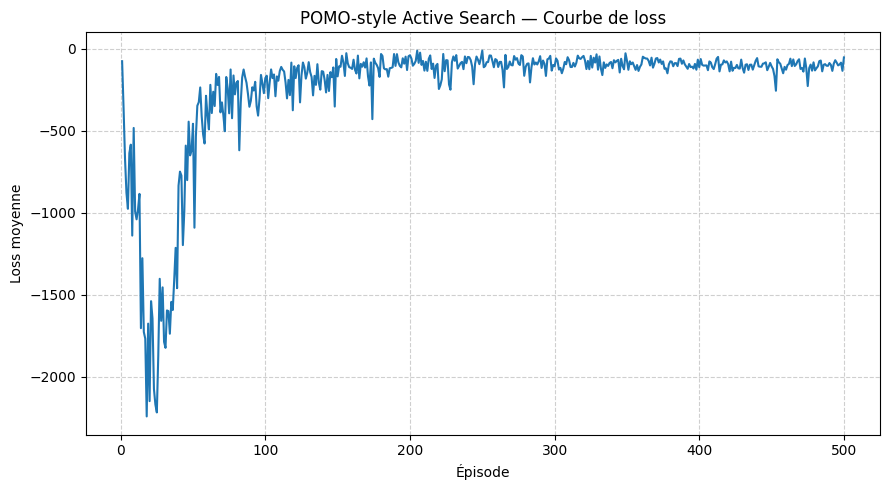

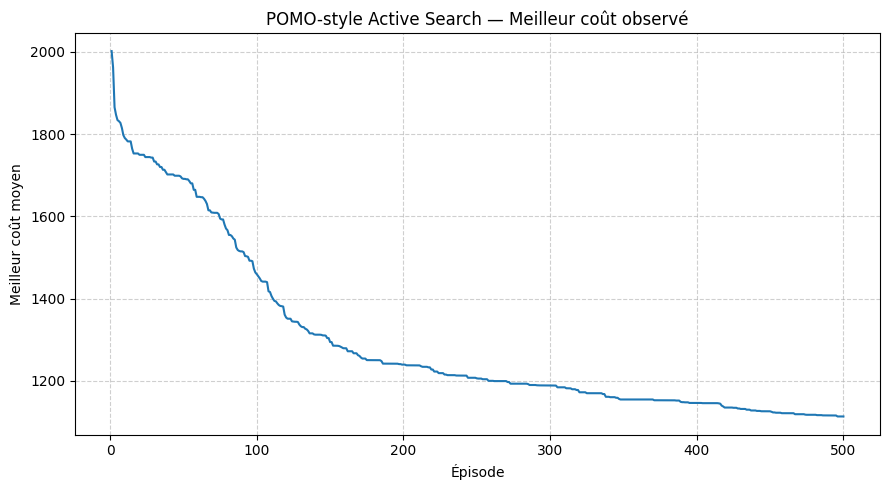

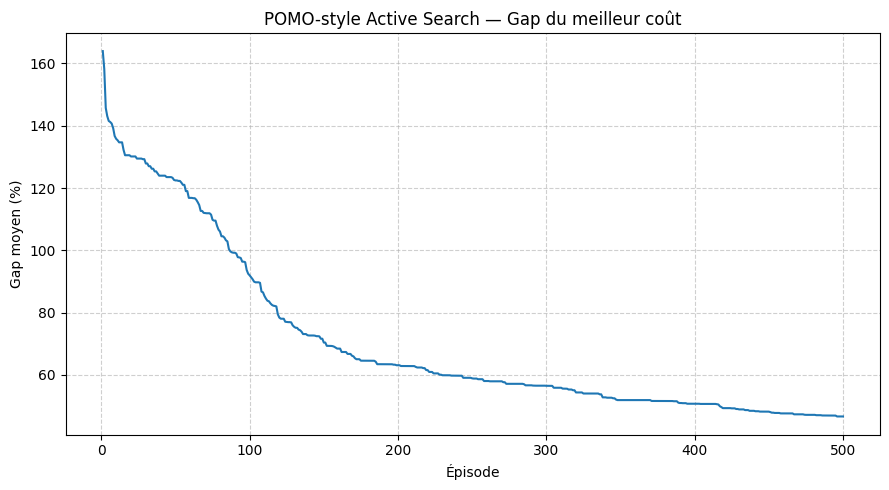

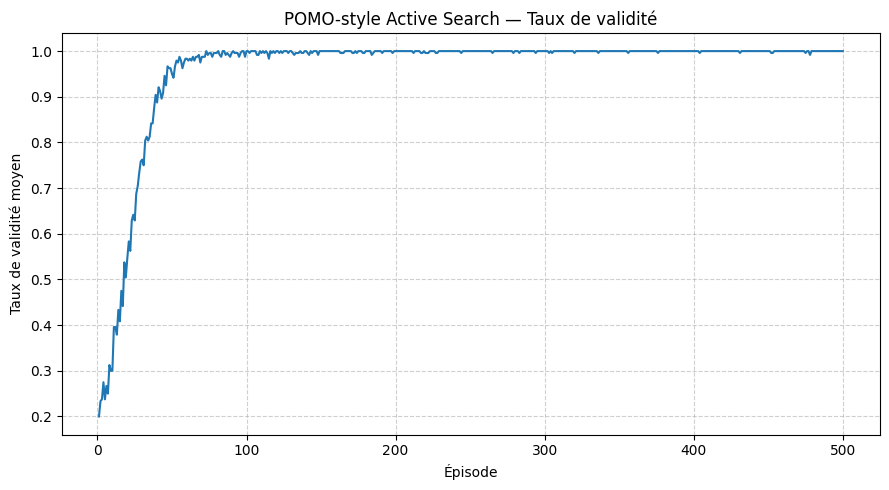

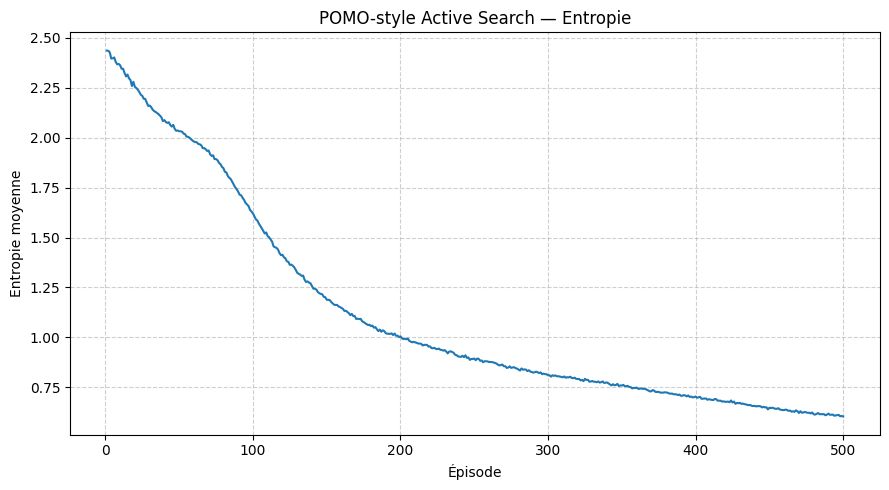

Figures sauvegardées :
- f:\code\projects\tfc\export_windows\results\pomo\figures\pomo_loss_curve.png
- f:\code\projects\tfc\export_windows\results\pomo\figures\pomo_best_cost_curve.png
- f:\code\projects\tfc\export_windows\results\pomo\figures\pomo_gap_curve.png
- f:\code\projects\tfc\export_windows\results\pomo\figures\pomo_valid_rate_curve.png
- f:\code\projects\tfc\export_windows\results\pomo\figures\pomo_entropy_curve.png


In [9]:
figures_dir = ROOT_DIR / CONFIG["figures_dir"]
figures_dir.mkdir(parents=True, exist_ok=True)

plot_df = training_df.copy()

episode_mean = plot_df.groupby("episode").agg(
    loss_mean=("loss", "mean"),
    policy_loss_mean=("policy_loss", "mean"),
    entropy_mean=("entropy", "mean"),
    valid_rate_mean=("valid_rate", "mean"),
    avg_cost_valid_mean=("avg_cost_valid", "mean"),
    avg_gap_valid_mean=("avg_gap_valid", "mean"),
    episode_best_cost_mean=("episode_best_cost", "mean"),
    best_cost_so_far_mean=("best_cost_so_far", "mean"),
    best_gap_so_far_mean=("best_gap_so_far", "mean"),
).reset_index()

# 1. Loss
plt.figure(figsize=(9, 5))
plt.plot(episode_mean["episode"], episode_mean["loss_mean"])
plt.xlabel("Épisode")
plt.ylabel("Loss moyenne")
plt.title("POMO-style Active Search — Courbe de loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
loss_path = figures_dir / "pomo_loss_curve.png"
plt.savefig(loss_path, dpi=200)
plt.show()

# 2. Best cost so far
plt.figure(figsize=(9, 5))
plt.plot(episode_mean["episode"], episode_mean["best_cost_so_far_mean"])
plt.xlabel("Épisode")
plt.ylabel("Meilleur coût moyen")
plt.title("POMO-style Active Search — Meilleur coût observé")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
best_cost_path = figures_dir / "pomo_best_cost_curve.png"
plt.savefig(best_cost_path, dpi=200)
plt.show()

# 3. Gap
plt.figure(figsize=(9, 5))
plt.plot(episode_mean["episode"], episode_mean["best_gap_so_far_mean"])
plt.xlabel("Épisode")
plt.ylabel("Gap moyen (%)")
plt.title("POMO-style Active Search — Gap du meilleur coût")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
gap_path = figures_dir / "pomo_gap_curve.png"
plt.savefig(gap_path, dpi=200)
plt.show()

# 4. Valid rate
plt.figure(figsize=(9, 5))
plt.plot(episode_mean["episode"], episode_mean["valid_rate_mean"])
plt.xlabel("Épisode")
plt.ylabel("Taux de validité moyen")
plt.title("POMO-style Active Search — Taux de validité")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
valid_path = figures_dir / "pomo_valid_rate_curve.png"
plt.savefig(valid_path, dpi=200)
plt.show()

# 5. Entropy
plt.figure(figsize=(9, 5))
plt.plot(episode_mean["episode"], episode_mean["entropy_mean"])
plt.xlabel("Épisode")
plt.ylabel("Entropie moyenne")
plt.title("POMO-style Active Search — Entropie")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
entropy_path = figures_dir / "pomo_entropy_curve.png"
plt.savefig(entropy_path, dpi=200)
plt.show()

print("Figures sauvegardées :")
print("-", loss_path)
print("-", best_cost_path)
print("-", gap_path)
print("-", valid_path)
print("-", entropy_path)

## Courbes par seed

Ces courbes montrent si l’apprentissage est stable d’une seed à l’autre.

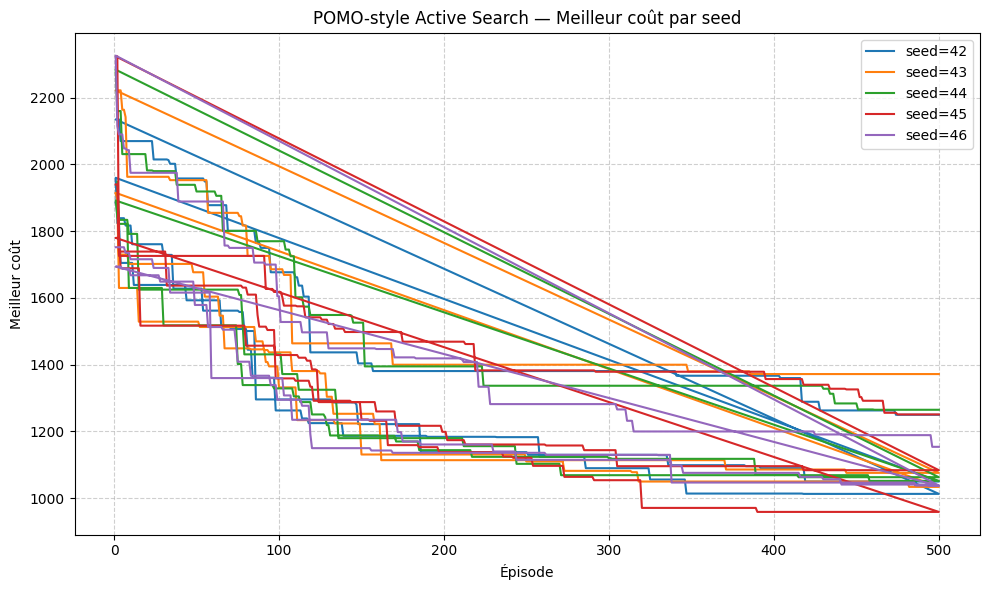

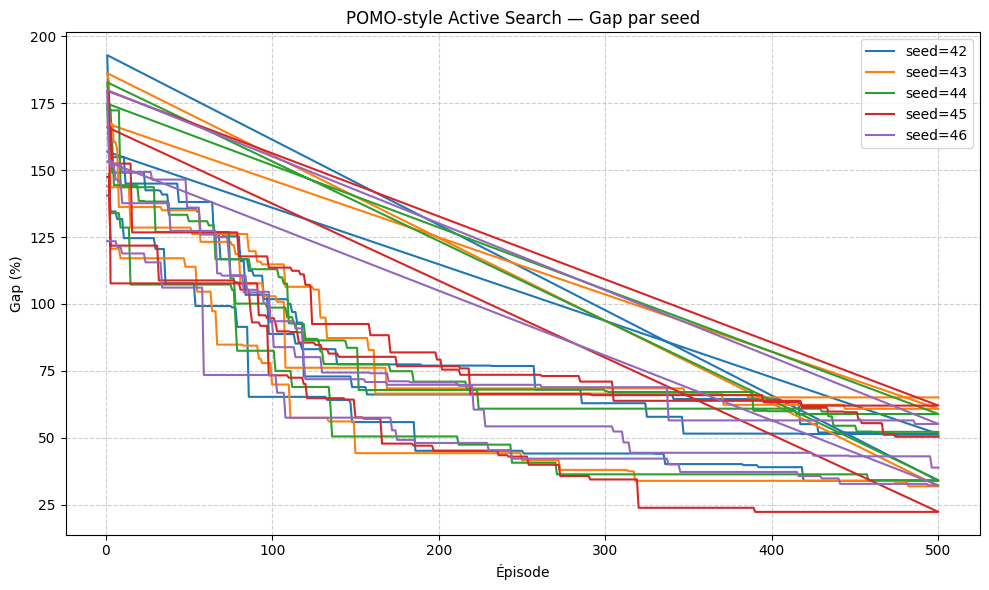

Figures par seed :
- f:\code\projects\tfc\export_windows\results\pomo\figures\pomo_best_cost_by_seed.png
- f:\code\projects\tfc\export_windows\results\pomo\figures\pomo_gap_by_seed.png


In [10]:
# Best cost par seed
plt.figure(figsize=(10, 6))

for seed, seed_df in plot_df.groupby("seed"):
    plt.plot(seed_df["episode"], seed_df["best_cost_so_far"], label=f"seed={seed}")

plt.xlabel("Épisode")
plt.ylabel("Meilleur coût")
plt.title("POMO-style Active Search — Meilleur coût par seed")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
seed_cost_path = figures_dir / "pomo_best_cost_by_seed.png"
plt.savefig(seed_cost_path, dpi=200)
plt.show()

# Gap par seed
plt.figure(figsize=(10, 6))

for seed, seed_df in plot_df.groupby("seed"):
    plt.plot(seed_df["episode"], seed_df["best_gap_so_far"], label=f"seed={seed}")

plt.xlabel("Épisode")
plt.ylabel("Gap (%)")
plt.title("POMO-style Active Search — Gap par seed")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
seed_gap_path = figures_dir / "pomo_gap_by_seed.png"
plt.savefig(seed_gap_path, dpi=200)
plt.show()

print("Figures par seed :")
print("-", seed_cost_path)
print("-", seed_gap_path)

## Lecture rapide des meilleurs résultats

Ce tableau trie les méthodes POMO par coût croissant.

In [11]:
best_table = experiments_df.sort_values(
    ["instance", "cost", "gap_percent"],
    ascending=[True, True, True],
)

display(best_table)

best_table_output_path = ROOT_DIR / CONFIG["output_dir"] / "pomo_best_table.csv"
best_table.to_csv(best_table_output_path, index=False, encoding="utf-8")

print("Table triée sauvegardée :", best_table_output_path)

,instance,method,category,seed,cost,reference_cost,gap_percent,routes,vehicle_count,is_valid,missing_customers_count,duplicated_customers_count,capacity_violations_count,train_time_sec,inference_time_sec,postprocess_time_sec,total_time_sec,episodes,notes
23,A-n32-k5,POMO-style best sampled + 2-opt,rl_main_local_search,45,912.0,784,16.326531,5,5,True,0,0,0,725.671981,0.000000,0.002153,725.674134,500,Meilleure solution active search améliorée par...
1,A-n32-k5,POMO-style multi-greedy + 2-opt,rl_main_local_search,42,916.0,784,16.836735,5,5,True,0,0,0,720.107417,0.387994,0.001747,720.497158,500,POMO-style multi-greedy amélioré par 2-opt int...
13,A-n32-k5,POMO-style multi-greedy + 2-opt,rl_main_local_search,44,916.0,784,16.836735,5,5,True,0,0,0,731.443949,0.426326,0.001891,731.872166,500,POMO-style multi-greedy amélioré par 2-opt int...
25,A-n32-k5,POMO-style multi-greedy + 2-opt,rl_main_local_search,46,925.0,784,17.984694,5,5,True,0,0,0,726.499895,0.380346,0.001415,726.881656,500,POMO-style multi-greedy amélioré par 2-opt int...
7,A-n32-k5,POMO-style multi-greedy + 2-opt,rl_main_local_search,43,928.0,784,18.367347,5,5,True,0,0,0,724.496499,0.416317,0.001545,724.914361,500,POMO-style multi-greedy amélioré par 2-opt int...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,A-n39-k6,POMO-style sampled eval,rl_main,44,1332.0,831,60.288809,6,6,True,0,0,0,933.042927,9.748531,0.000000,942.791458,500,POMO-style Active Search évalué par sampling (...
72,A-n39-k6,POMO-style multi-greedy,rl_main,44,1348.0,831,62.214200,6,6,True,0,0,0,933.042927,0.481033,0.000000,933.523960,500,POMO-style Active Search évalué en multi-greedy.
70,A-n39-k6,POMO-style best sampled,rl_main,43,1372.0,831,65.102286,6,6,True,0,0,0,903.868760,0.000000,0.000000,903.868760,500,Meilleure solution valide rencontrée pendant l...
68,A-n39-k6,POMO-style sampled eval,rl_main,43,1500.0,831,80.505415,6,6,True,0,0,0,903.868760,9.620312,0.000000,913.489071,500,POMO-style Active Search évalué par sampling (...


Table triée sauvegardée : f:\code\projects\tfc\export_windows\results\pomo\pomo_best_table.csv


## Sauvegarde JSON des meilleures routes

Le JSON permet de réutiliser les routes dans la rédaction, la visualisation ou l’agrégation finale.

In [12]:
routes_json = []

for row in all_final_rows:
    # Les routes ne sont pas stockées dans le CSV final pour garder un format propre.
    # On les récupère en régénérant uniquement les métadonnées utiles déjà connues dans les lignes finales.
    routes_json.append({
        "instance": row["instance"],
        "method": row["method"],
        "seed": row["seed"],
        "cost": row["cost"],
        "gap_percent": row["gap_percent"],
        "is_valid": row["is_valid"],
        "routes_count": row["routes"],
        "notes": row["notes"],
    })

routes_json_path = ROOT_DIR / CONFIG["routes_dir"] / "pomo_routes_index.json"

with routes_json_path.open("w", encoding="utf-8") as file:
    json.dump(routes_json, file, indent=2, ensure_ascii=False)

print("Index JSON sauvegardé :", routes_json_path)

Index JSON sauvegardé : f:\code\projects\tfc\export_windows\results\pomo\routes\pomo_routes_index.json


## Conclusion technique du notebook

À vérifier après exécution :

```text
results/pomo/experiments_pomo.csv
results/pomo/training_metrics_pomo.csv
results/pomo/summary_pomo_by_seed.csv
results/pomo/figures/
results/pomo/routes/
results/pomo/models/
```

Le fichier `experiments_pomo.csv` doit avoir exactement les mêmes colonnes que :
- `results/heuristics/experiments_heuristics.csv`
- `results/q_learning/experiments_q_learning.csv`

C’est ce qui permettra ensuite de produire le tableau final du mémoire.